# AR Identifier Quality Assurance

Notebook to identify performance of the AR clustering code.

Jimmy Butler, August 2024

In [1]:
import os
from pathlib import Path
import numpy as np
import pandas as pd
import dask
import xarray as xr
import seaborn as sns
import matplotlib.pyplot as plt
from sklearn.cluster import DBSCAN
from sklearn.metrics.pairwise import haversine_distances
import math
from tqdm import tqdm

os.chdir('/accounts/grad/butlerj/extreme_antarctic_ARs/scripts')

import st_dbscan as st

from utils import arctan
from utils import average_angle
from utils import retrieve_neighbors
from utils import construct_da
from utils import is_landfalling
import utils

In [2]:
# loading up Jonathan's catalogs
catalog_path = '~/extreme_antarctic_ARs/data/ar_catalogs/'
orig_catalog = xr.open_mfdataset(catalog_path + '*.nc')

In [3]:
orig_catalog

<xarray.Dataset> Size: 26GB
Dimensions:        (time: 125648, lat: 361, lon: 576)
Coordinates:
  * lat            (lat) float64 3kB -90.0 -89.5 -89.0 -88.5 ... 89.0 89.5 90.0
  * lon            (lon) float64 5kB -180.0 -179.4 -178.8 ... 178.1 178.8 179.4
  * time           (time) datetime64[ns] 1MB 1980-01-01 ... 2022-12-31T21:00:00
Data variables:
    ar_binary_tag  (time, lat, lon) int8 26GB dask.array<chunksize=(1, 361, 576), meta=np.ndarray>
Attributes:
    CDI:          Climate Data Interface version 1.9.6 (http://mpimet.mpg.de/...
    Conventions:  CF-1.6
    history:      Thu Feb  9 11:32:59 2023: ncks -4 -L 1 temp_MERRA2.ar_tag.W...
    description:  ARTMIP file format (Ullrich)
    NCO:          netCDF Operators version 5.0.0 (Homepage = http://nco.sf.ne...
    CDO:          Climate Data Operators version 1.9.6 (http://mpimet.mpg.de/...

## Ground-Truth Comparisons

## Sensitivity Analysis

### 1. Changing the Random Seed

In [4]:
f_names = os.listdir('/scratch/users/butlerj/extreme_antarctic_ars/sensitivity_analysis/seed/')
dataframes = [None]*(len(f_names) + 1)
dataarrays = [None]*(len(f_names) + 1)

scratch_path = '/scratch/users/butlerj/extreme_antarctic_ars/sensitivity_analysis/'
dataframes[0] = pd.read_pickle(scratch_path + 'baseline/storm_df.pkl').drop(-1)
dataarrays[0] = xr.open_dataset(scratch_path + 'baseline/storm_da.nc')

for i, f_name in enumerate(f_names):
    
    dataframes[i+1] = pd.read_pickle(scratch_path + 'seed/' + f_name + '/storm_df.pkl').drop(-1)
    dataarrays[i+1] = xr.open_dataset(scratch_path + 'seed/' + f_name + '/storm_da.nc')

In [4]:
storms = [None]*len(dataframes)
landfalling_storms = [None]*len(dataframes)

for i in range(len(dataframes)):
    storms[i] = len(dataframes[i])
    landfalling_storms[i] = len(dataframes[i][dataframes[i]['is_landfalling']])

#### Number of Storms (total)

In [5]:
storms

[1682, 1696, 1680, 1705, 1685, 1699]

#### Number of Storms (landfalling)

In [6]:
landfalling_storms

[615, 615, 615, 615, 612, 615]

#### Comparisons with Jonathan's Catalog

In [12]:
diffs = np.zeros(len(dataarrays))
num_px = np.zeros(len(dataarrays))

# compute the pixel-by-pixel difference between the catalog and the identifier for each param config
for i in tqdm(range(len(dataarrays))):
    
    identifier_dat = dataarrays[i]
    no_noise = identifier_dat.where(identifier_dat.cluster != -1, 0)
    catalog_dat = orig_catalog.sel(time = identifier_dat.time)
    catalog_dat = catalog_dat.sel(lat = identifier_dat.lat)
    id_ar_pts = no_noise.cluster != 0
    cat_ar_pts = catalog_dat.ar_binary_tag != 0
    
    diffs[i] = int((id_ar_pts != cat_ar_pts).to_numpy().sum())
    num_px[i] = int(cat_ar_pts.sum().to_numpy())

100%|██████████| 6/6 [08:43<00:00, 87.33s/it]


In [16]:
diffs

array([45981., 37361., 31909., 42163., 37054., 42969.])

In [18]:
diffs/num_px

array([0.00519355, 0.00421992, 0.00360412, 0.00476231, 0.00418525,
       0.00485335])

### 2. Changing spatial epsilon

In [25]:
f_names = os.listdir('/scratch/users/butlerj/extreme_antarctic_ars/sensitivity_analysis/eps_space/')
dataframes = {}
dataarrays = {}

scratch_path = '/scratch/users/butlerj/extreme_antarctic_ars/sensitivity_analysis/'
dataframes['eps_space_0.5'] = pd.read_pickle(scratch_path + 'baseline/storm_df.pkl').drop(-1)
dataarrays['eps_space_0.5'] = xr.open_dataset(scratch_path + 'baseline/storm_da.nc')

for i, f_name in enumerate(f_names):
    
    dataframes[f_name] = pd.read_pickle(scratch_path + 'eps_space/' + f_name + '/storm_df.pkl').drop(-1)
    dataarrays[f_name] = xr.open_dataset(scratch_path + 'eps_space/' + f_name + '/storm_da.nc')

In [33]:
storms = {}
landfalling_storms = {}

for i, f_name in enumerate(dataframes.keys()):
    storms[f_name] = len(dataframes[f_name])
    landfalling_storms[f_name] = len(dataframes[f_name][dataframes[f_name]['is_landfalling']])

#### Number of Storms (total)

In [34]:
storms

{'eps_space_0.5': 1682, 'eps_space_1': 1496, 'eps_space_0.25': 2218}

#### Number of Storms (landfalling)

In [35]:
landfalling_storms

{'eps_space_0.5': 615, 'eps_space_1': 587, 'eps_space_0.25': 691}

### 3. Changing time epsilon

In [36]:
f_names = os.listdir('/scratch/users/butlerj/extreme_antarctic_ars/sensitivity_analysis/eps_time/')
dataframes = {}
dataarrays = {}

scratch_path = '/scratch/users/butlerj/extreme_antarctic_ars/sensitivity_analysis/'
dataframes['eps_time_18'] = pd.read_pickle(scratch_path + 'baseline/storm_df.pkl').drop(-1)
dataarrays['eps_time_18'] = xr.open_dataset(scratch_path + 'baseline/storm_da.nc')

for i, f_name in enumerate(f_names):
    
    dataframes[f_name] = pd.read_pickle(scratch_path + 'eps_time/' + f_name + '/storm_df.pkl').drop(-1)
    dataarrays[f_name] = xr.open_dataset(scratch_path + 'eps_time/' + f_name + '/storm_da.nc')

In [37]:
storms = {}
landfalling_storms = {}

for i, f_name in enumerate(dataframes.keys()):
    storms[f_name] = len(dataframes[f_name])
    landfalling_storms[f_name] = len(dataframes[f_name][dataframes[f_name]['is_landfalling']])

#### Number of Storms (total)

In [38]:
storms

{'eps_time_18': 1682, 'eps_time_12': 1820, 'eps_time_24': 1596}

#### Number of Storms (landfalling)

In [39]:
landfalling_storms

{'eps_time_18': 615, 'eps_time_12': 655, 'eps_time_24': 586}

### 4. Changing mininum points

In [40]:
f_names = os.listdir('/scratch/users/butlerj/extreme_antarctic_ars/sensitivity_analysis/min_pts/')
dataframes = {}
dataarrays = {}

scratch_path = '/scratch/users/butlerj/extreme_antarctic_ars/sensitivity_analysis/'
dataframes['min_pts_5'] = pd.read_pickle(scratch_path + 'baseline/storm_df.pkl').drop(-1)
dataarrays['min_pts_5'] = xr.open_dataset(scratch_path + 'baseline/storm_da.nc')

for i, f_name in enumerate(f_names):
    
    dataframes[f_name] = pd.read_pickle(scratch_path + 'min_pts/' + f_name + '/storm_df.pkl').drop(-1)
    dataarrays[f_name] = xr.open_dataset(scratch_path + 'min_pts/' + f_name + '/storm_da.nc')

In [41]:
storms = {}
landfalling_storms = {}

for i, f_name in enumerate(dataframes.keys()):
    storms[f_name] = len(dataframes[f_name])
    landfalling_storms[f_name] = len(dataframes[f_name][dataframes[f_name]['is_landfalling']])

#### Number of Storms (total)

In [42]:
storms

{'min_pts_5': 1682, 'min_pts_3': 1717, 'min_pts_10': 1540}

#### Number of Storms (landfalling)

In [43]:
landfalling_storms

{'min_pts_5': 615, 'min_pts_3': 615, 'min_pts_10': 585}

### 5. Changing number of representative points

In [44]:
f_names = os.listdir('/scratch/users/butlerj/extreme_antarctic_ars/sensitivity_analysis/rep_pts/')
dataframes = {}
dataarrays = {}

scratch_path = '/scratch/users/butlerj/extreme_antarctic_ars/sensitivity_analysis/'
dataframes['rep_pts_10'] = pd.read_pickle(scratch_path + 'baseline/storm_df.pkl').drop(-1)
dataarrays['rep_pts_10'] = xr.open_dataset(scratch_path + 'baseline/storm_da.nc')

for i, f_name in enumerate(f_names):
    
    dataframes[f_name] = pd.read_pickle(scratch_path + 'rep_pts/' + f_name + '/storm_df.pkl').drop(-1)
    dataarrays[f_name] = xr.open_dataset(scratch_path + 'rep_pts/' + f_name + '/storm_da.nc')

In [46]:
storms = {}
landfalling_storms = {}

for i, f_name in enumerate(dataframes.keys()):
    storms[f_name] = len(dataframes[f_name])
    landfalling_storms[f_name] = len(dataframes[f_name][dataframes[f_name]['is_landfalling']])

#### Number of Storms (total)

In [47]:
storms

{'rep_pts_10': 1682, 'rep_pts_15': 1658, 'rep_pts_5': 1696}

#### Number of Storms (landfalling)

In [48]:
landfalling_storms

{'rep_pts_10': 615, 'rep_pts_15': 605, 'rep_pts_5': 612}

### Comparisons with Jonathan's Catalog

In [2]:
scratch_path = '/scratch/users/butlerj/extreme_antarctic_ars/datarrays/'
catalog_path = '/accounts/grad/butlerj/extreme_antarctic_ARs/data/ar_catalogs/'
identifier_files = sorted(os.listdir(scratch_path))
jonathans_files = sorted(os.listdir(catalog_path))

diffs = np.zeros(len(identifier_files))

# compute the pixel-by-pixel difference between the catalog and the identifier
for i in range(len(identifier_files)):
    
    identifier_dat = xr.open_dataset(scratch_path + identifier_files[i])
    catalog_dat = xr.open_dataset(catalog_path + jonathans_files[i])
    catalog_dat = catalog_dat.sel(lat=slice(-86, -39))
    id_ar_pts = identifier_dat.cluster != 0
    cat_ar_pts = catalog_dat.ar_binary_tag != 0
    
    diffs[i] = int((id_ar_pts != cat_ar_pts).to_numpy().sum())
    
num_diffs = int(sum(diffs))
print(f'Pixel Differences with Jonathan\'s Catalog: {num_diffs}')

Pixel Differences with Jonathan's Catalog: 0


In [4]:
scratch_path = '/scratch/users/butlerj/extreme_antarctic_ars/datarrays/'
catalog_path = '/accounts/grad/butlerj/extreme_antarctic_ARs/data/ar_catalogs/'
identifier_files = sorted(os.listdir(scratch_path))
jonathans_files = sorted(os.listdir(catalog_path))

diffs = np.zeros(len(identifier_files))
num_px = np.zeros(len(identifier_files))

# compute the pixel-by-pixel difference between the catalog and the identifier
for i in range(len(identifier_files)):
    
    identifier_dat = xr.open_dataset(scratch_path + identifier_files[i])
    no_noise = identifier_dat.where(identifier_dat.cluster != -1, 0)
    catalog_dat = xr.open_dataset(catalog_path + jonathans_files[i])
    catalog_dat = catalog_dat.sel(lat=slice(-86, -39))
    id_ar_pts = no_noise.cluster != 0
    cat_ar_pts = catalog_dat.ar_binary_tag != 0
    
    diffs[i] = int((id_ar_pts != cat_ar_pts).to_numpy().sum())
    num_px[i] = int(cat_ar_pts.sum().to_numpy())

Text(0, 0.5, '% Difference')

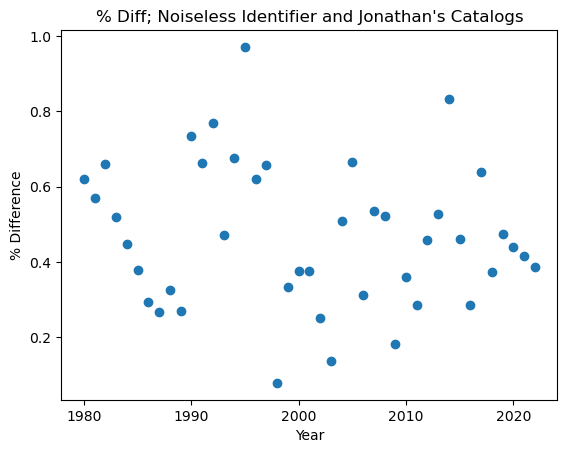

In [5]:
percent_diffs = diffs/num_px*100
years = np.arange(1980, 2023)

plt.scatter(x=years, y=percent_diffs)
plt.title('% Diff; Noiseless Identifier and Jonathan\'s Catalogs')
plt.xlabel('Year')
plt.ylabel('% Difference')

### Storm Counts

In [6]:
scratch_path = '/scratch/users/butlerj/extreme_antarctic_ars/dataframes/'
identifier_dfs = sorted(os.listdir(scratch_path))

storm_cts = np.zeros(len(identifier_dfs))
years = np.zeros(len(identifier_dfs))

for i in range(len(identifier_dfs)):
    
    cur_df = pd.read_csv(scratch_path + identifier_dfs[i])
    # subtract one to exclude noise clusters
    storm_cts[i] = len(cur_df.cluster.value_counts().index) - 1
    years[i] = int(cur_df.time.loc[0][0:4])

Text(0.5, 1.0, 'Number of Individual Storms')

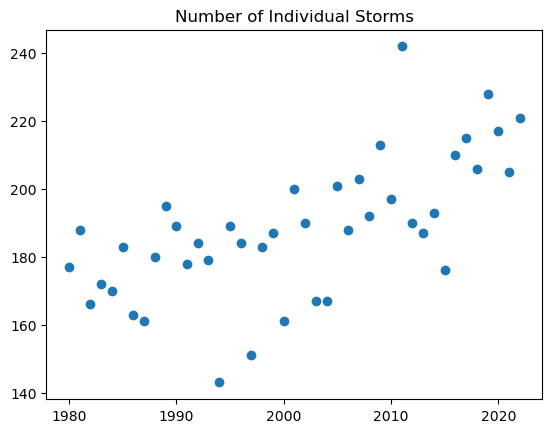

In [7]:
plt.scatter(x = years, y= storm_cts)
plt.title('Number of Individual Storms')

In [27]:
scratch_path = '/scratch/users/butlerj/extreme_antarctic_ars/dataframes/'
identifier_dfs = sorted(os.listdir(scratch_path))

storm_cts = np.zeros(len(identifier_dfs))
years = np.zeros(len(identifier_dfs))

for i in range(len(identifier_dfs)):
    
    cur_df = pd.read_csv(scratch_path + identifier_dfs[i])
    # subtract one to exclude noise clusters
    storm_cts[i] = cur_df.loc[cur_df.is_landfalling].cluster.value_counts().shape[0]
    years[i] = int(cur_df.time.loc[0][0:4])

Text(0.5, 1.0, 'Number of Landfalling Storms')

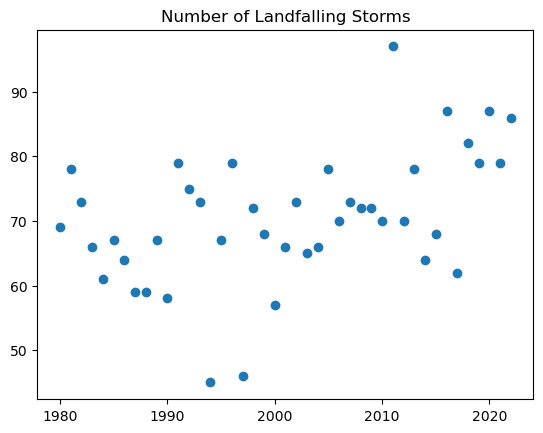

In [28]:
plt.scatter(x = years, y= storm_cts)
plt.title('Number of Landfalling Storms')